# Analyse du succès commercial et de la rentabilité des films Bollywood

Ce notebook étudie deux cibles :
- **Success_Class** : classe de succès commercial dérivée de `Revenue(INR)`
- **Profitability_Class** : classe de rentabilité dérivée du **ROI**

Les variables explicatives principales sont :
- `Votes`
- `Budget(INR)`
- `Number of Screens`
- `Rating(10)`
- `Genre`

Deux modèles sont comparés :
- **Gaussian Naive Bayes**
- **Random Forest**

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams["figure.figsize"] = (8, 5)


## 1. Chargement des données

In [6]:
DATA_PATH = "../Bollywood_Movies_data//bollywood_merged_clean.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Movie Name,Release Period,Genre,New Music Director,Number of Screens,Revenue(INR),Budget(INR),Timing(min),Rating(10),Votes,Language,Profit(INR),ROI
0,apna sapna money money,normal,comedy,no,450,95000000,207325000,134.0,5.3,1892.0,hindi,-112325000,0.458218
1,sunday,holiday,comedy,no,900,220000000,319615000,135.0,5.3,2592.0,hindi,-99615000,0.688328
2,highway,holiday,drama,no,750,250000000,477065000,133.0,7.6,26801.0,hindi,-227065000,0.524038
3,golmaal returns,holiday,comedy,yes,1250,350000000,800080000,135.0,5.1,7115.0,hindi,-450080000,0.437456
4,that girl in yellow boots,normal,drama,yes,200,40000000,27100000,103.0,6.6,3574.0,kannada,12900000,1.476015


In [7]:
print("Dimensions :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())
print("\nValeurs manquantes :")
print(df.isna().sum())
print("\nDoublons :", df.duplicated().sum())

Dimensions : (1335, 13)

Colonnes :
['Movie Name', 'Release Period', 'Genre', 'New Music Director', 'Number of Screens', 'Revenue(INR)', 'Budget(INR)', 'Timing(min)', 'Rating(10)', 'Votes', 'Language', 'Profit(INR)', 'ROI']

Valeurs manquantes :
Movie Name            0
Release Period        0
Genre                 0
New Music Director    0
Number of Screens     0
Revenue(INR)          0
Budget(INR)           0
Timing(min)           0
Rating(10)            0
Votes                 0
Language              0
Profit(INR)           0
ROI                   0
dtype: int64

Doublons : 11


## 2. Sélection des variables et création des cibles

In [8]:
data = df[['Movie Name', 'Genre', 'Budget(INR)', 'Number of Screens', 'Rating(10)', 'Votes', 'Revenue(INR)']].copy()

# ROI : rentabilité relative
data['ROI'] = data['Revenue(INR)'] / data['Budget(INR)']

# Classes de succès à partir du revenu (quantiles)
data['Success_Class'] = pd.qcut(
    data['Revenue(INR)'],
    q=3,
    labels=['Flop', 'Average', 'Hit']
)

# Classes de rentabilité à partir du ROI (quantiles)
data['Profitability_Class'] = pd.qcut(
    data['ROI'],
    q=3,
    labels=['Low ROI', 'Medium ROI', 'High ROI']
)

data.head()

,Movie Name,Genre,Budget(INR),Number of Screens,Rating(10),Votes,Revenue(INR),ROI,Success_Class,Profitability_Class
0,apna sapna money money,comedy,207325000,450,5.3,1892.0,95000000,0.458218,Average,Low ROI
1,sunday,comedy,319615000,900,5.3,2592.0,220000000,0.688328,Average,Low ROI
2,highway,drama,477065000,750,7.6,26801.0,250000000,0.524038,Hit,Low ROI
3,golmaal returns,comedy,800080000,1250,5.1,7115.0,350000000,0.437456,Hit,Low ROI
4,that girl in yellow boots,drama,27100000,200,6.6,3574.0,40000000,1.476015,Flop,Medium ROI


In [9]:
print("Distribution de Success_Class :")
print(data['Success_Class'].value_counts())
print("\nDistribution de Profitability_Class :")
print(data['Profitability_Class'].value_counts())

Distribution de Success_Class :
Success_Class
Flop       465
Average    437
Hit        433
Name: count, dtype: int64

Distribution de Profitability_Class :
Profitability_Class
Medium ROI    446
Low ROI       445
High ROI      444
Name: count, dtype: int64


## 3. Analyse exploratoire

In [10]:
num_cols = ['Budget(INR)', 'Number of Screens', 'Rating(10)', 'Votes', 'Revenue(INR)', 'ROI']
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Budget(INR),1335.0,3.666133e+08,7.402412e+08,14000.000000,6.414125e+06,6.940500e+07,4.175138e+08,7.024750e+09
Number of Screens,1335.0,8.093146e+02,8.815026e+02,1.000000,1.500000e+02,4.500000e+02,1.200000e+03,4.600000e+03
Rating(10),1335.0,5.625318e+00,1.459057e+00,1.700000,4.600000e+00,5.700000e+00,6.800000e+00,9.100000e+00
Votes,1335.0,5.450122e+03,1.560111e+04,5.000000,1.500000e+02,8.450000e+02,4.516000e+03,3.511870e+05
Revenue(INR),1335.0,2.194318e+08,2.751017e+08,1000000.000000,4.000000e+07,1.100000e+08,3.000000e+08,2.100000e+09
ROI,1335.0,1.150023e+01,7.588914e+01,0.119237,6.467249e-01,1.541082e+00,6.214888e+00,1.714286e+03


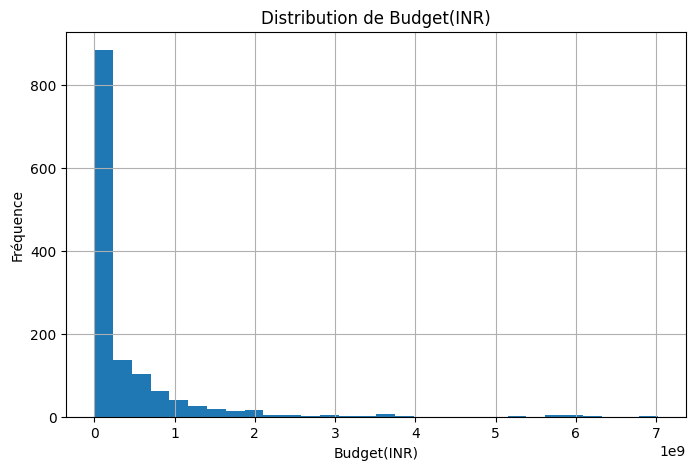

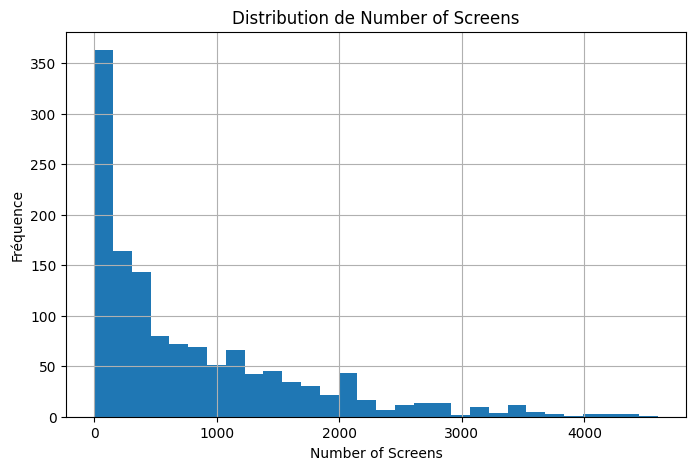

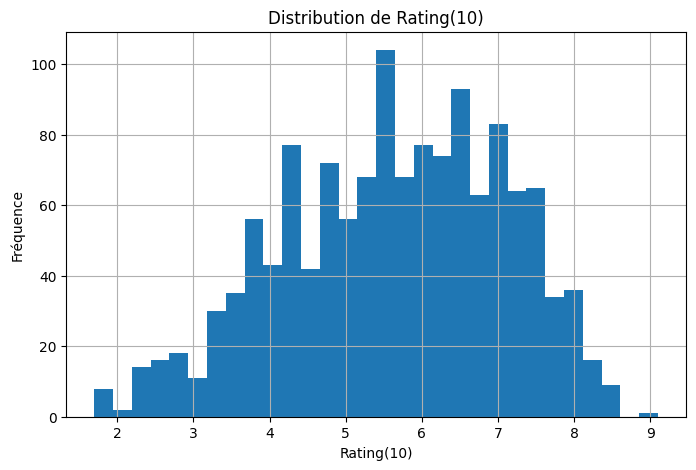

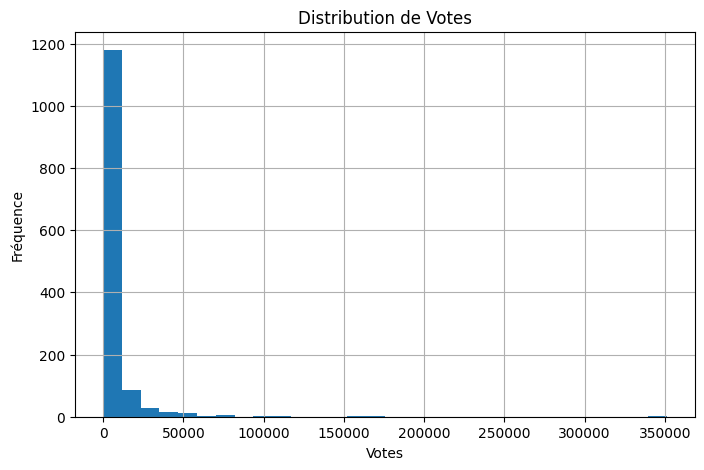

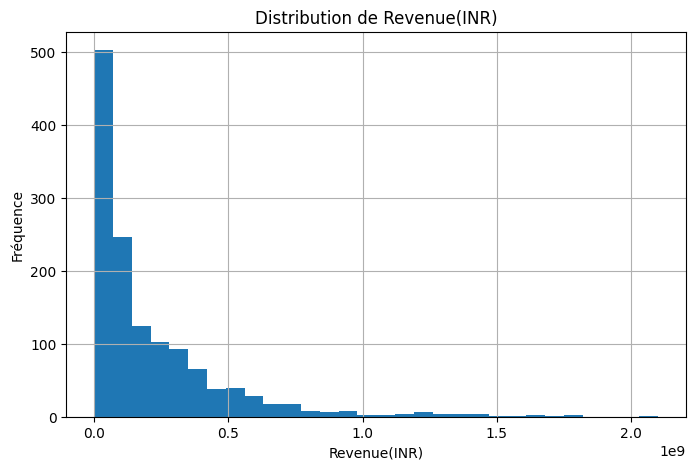

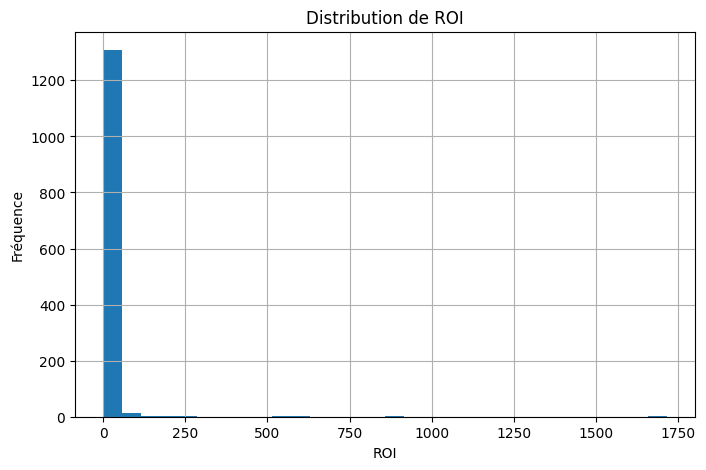

In [11]:
# Distributions principales
for col in ['Budget(INR)', 'Number of Screens', 'Rating(10)', 'Votes', 'Revenue(INR)', 'ROI']:
    plt.figure()
    data[col].hist(bins=30)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

In [12]:
# Corrélations
corr = data[['Budget(INR)', 'Number of Screens', 'Rating(10)', 'Votes', 'Revenue(INR)', 'ROI']].corr()
corr

,Budget(INR),Number of Screens,Rating(10),Votes,Revenue(INR),ROI
Budget(INR),1.000000,0.773061,0.169564,0.597181,0.836730,-0.071199
Number of Screens,0.773061,1.000000,0.000957,0.357103,0.899095,-0.119470
Rating(10),0.169564,0.000957,1.000000,0.292162,0.056618,-0.087479
Votes,0.597181,0.357103,0.292162,1.000000,0.415701,-0.047815
Revenue(INR),0.836730,0.899095,0.056618,0.415701,1.000000,-0.084165
ROI,-0.071199,-0.119470,-0.087479,-0.047815,-0.084165,1.000000


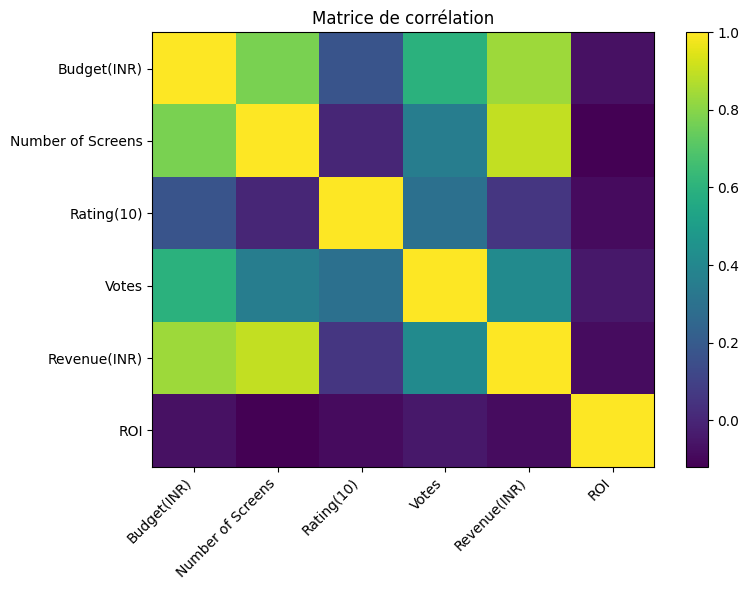

In [13]:
plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

### Analyse par genre

In [14]:
genre_summary = data.groupby('Genre')[['Revenue(INR)', 'ROI', 'Votes', 'Rating(10)', 'Budget(INR)', 'Number of Screens']].mean().sort_values('Revenue(INR)', ascending=False)
genre_summary.head(10)

,Revenue(INR),ROI,Votes,Rating(10),Budget(INR),Number of Screens
Genre,,,,,,
masala,9.117391e+08,0.527698,26061.086957,5.500000,2.683963e+09,3078.260870
action,4.771896e+08,2.730657,9065.391667,5.549167,9.567605e+08,1683.666667
fantasy,2.888333e+08,19.869857,1234.933333,4.573333,1.599604e+08,1058.000000
rom__com,2.267769e+08,4.063417,5412.703297,5.720879,3.660361e+08,817.252747
love_story,2.049330e+08,40.377016,5234.258929,5.437500,3.482783e+08,785.276786
thriller,1.980221e+08,5.086303,4370.524510,5.519608,2.293654e+08,814.392157
comedy,1.869774e+08,8.345661,3360.609053,5.034979,3.050167e+08,757.711934
drama,1.646059e+08,12.530574,5777.438559,6.139407,2.419056e+08,546.966102
horror,7.491667e+07,2.552543,825.100000,4.266667,7.869192e+07,546.200000


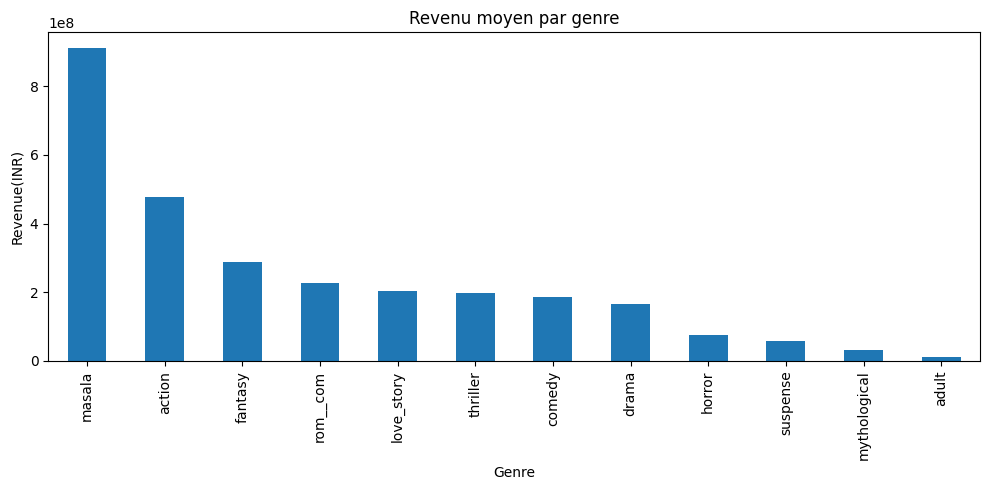

In [15]:
plt.figure(figsize=(10, 5))
genre_revenue = data.groupby('Genre')['Revenue(INR)'].mean().sort_values(ascending=False)
genre_revenue.plot(kind='bar')
plt.title("Revenu moyen par genre")
plt.ylabel("Revenue(INR)")
plt.tight_layout()
plt.show()

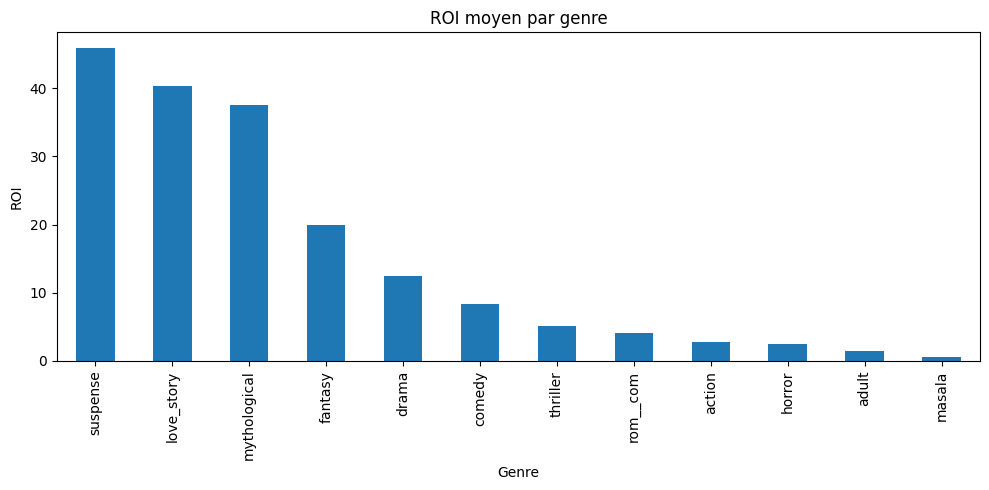

In [16]:
plt.figure(figsize=(10, 5))
genre_roi = data.groupby('Genre')['ROI'].mean().sort_values(ascending=False)
genre_roi.plot(kind='bar')
plt.title("ROI moyen par genre")
plt.ylabel("ROI")
plt.tight_layout()
plt.show()

### Variables selon la classe de succès

<Figure size 800x500 with 0 Axes>

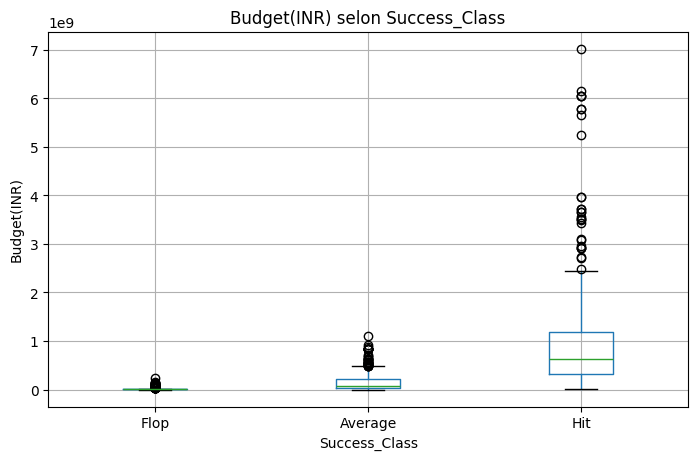

<Figure size 800x500 with 0 Axes>

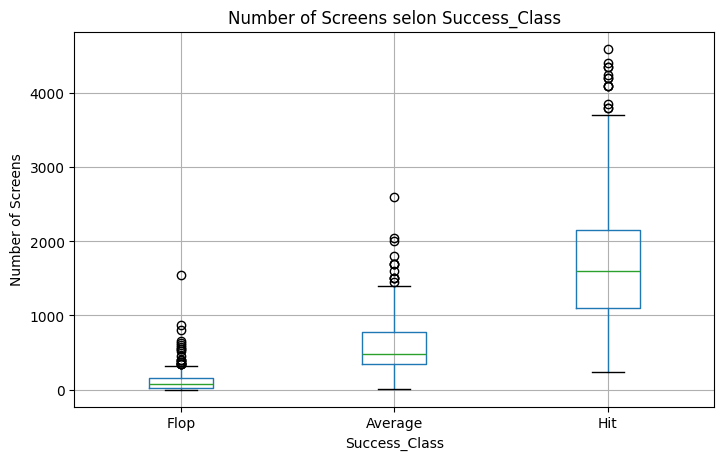

<Figure size 800x500 with 0 Axes>

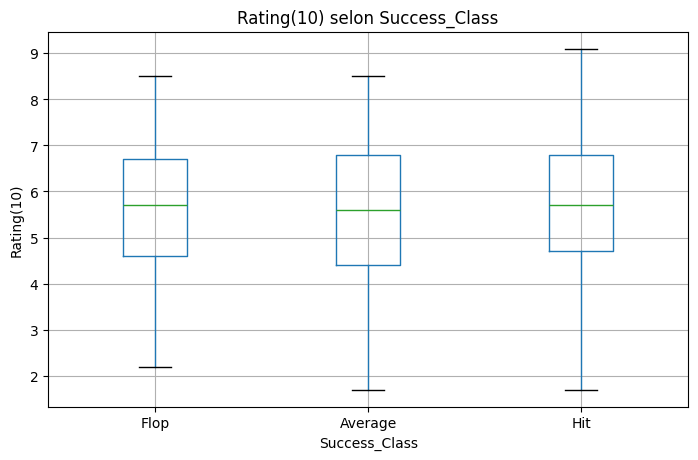

<Figure size 800x500 with 0 Axes>

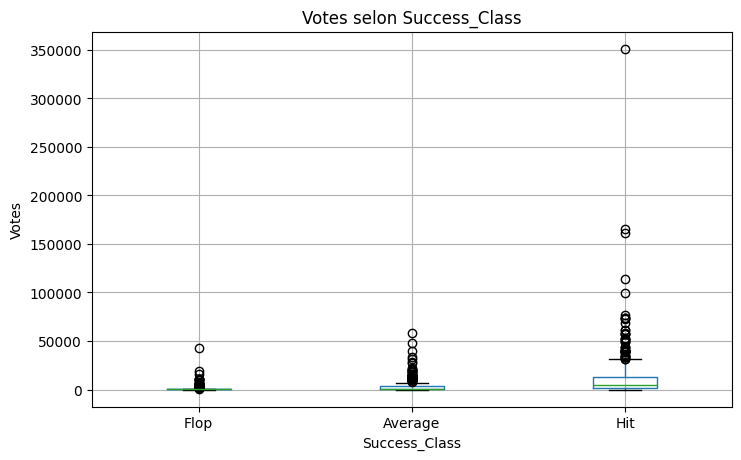

In [17]:
for col in ['Budget(INR)', 'Number of Screens', 'Rating(10)', 'Votes']:
    plt.figure()
    data.boxplot(column=col, by='Success_Class')
    plt.title(f"{col} selon Success_Class")
    plt.suptitle("")
    plt.xlabel("Success_Class")
    plt.ylabel(col)
    plt.show()

### Variables selon la classe de rentabilité

<Figure size 800x500 with 0 Axes>

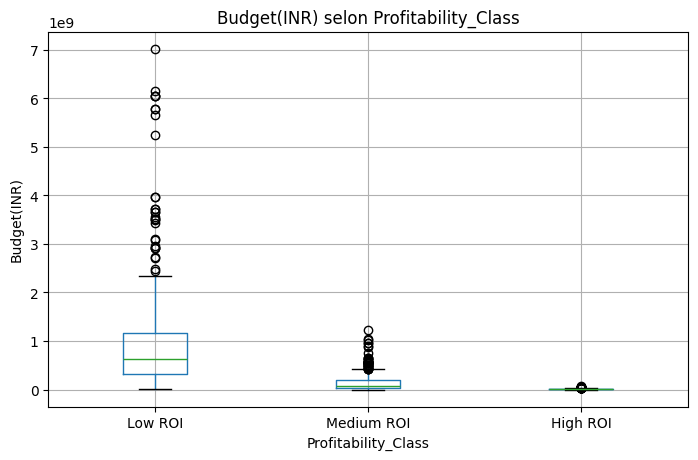

<Figure size 800x500 with 0 Axes>

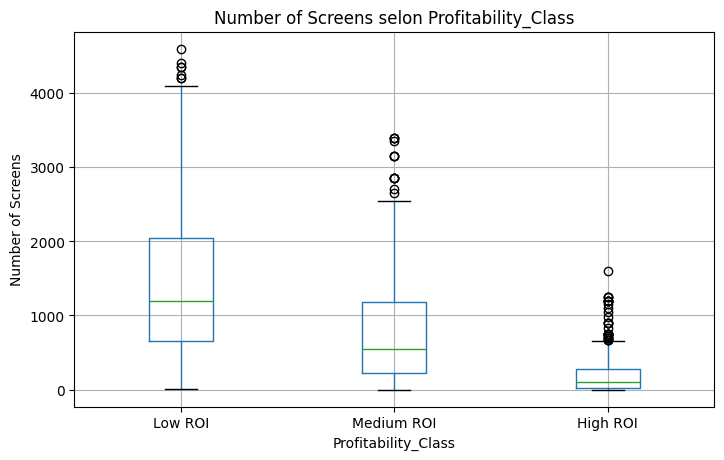

<Figure size 800x500 with 0 Axes>

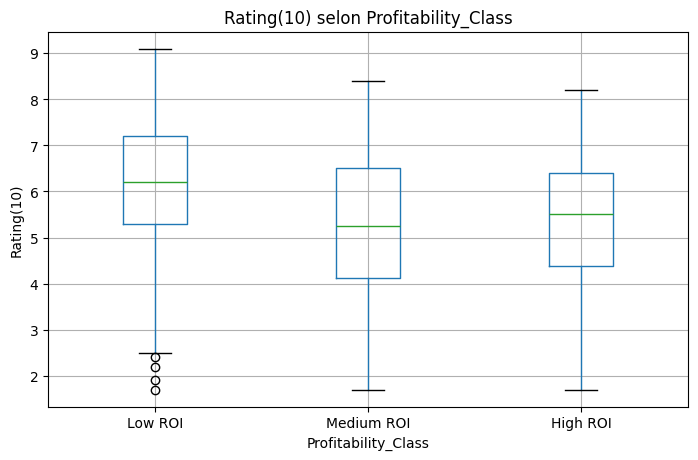

<Figure size 800x500 with 0 Axes>

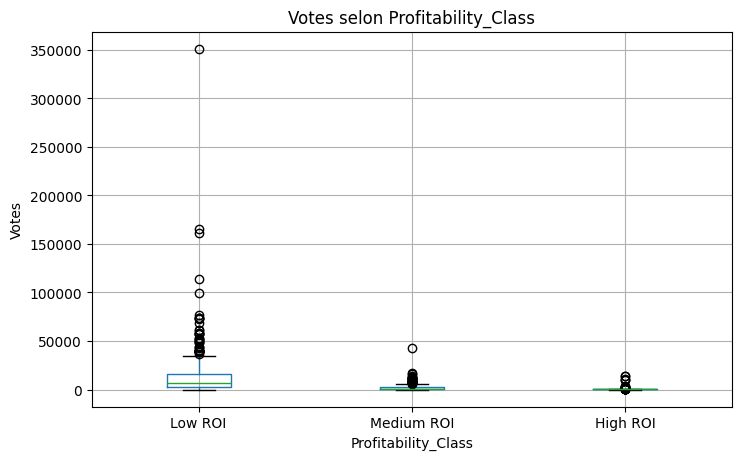

In [18]:
for col in ['Budget(INR)', 'Number of Screens', 'Rating(10)', 'Votes']:
    plt.figure()
    data.boxplot(column=col, by='Profitability_Class')
    plt.title(f"{col} selon Profitability_Class")
    plt.suptitle("")
    plt.xlabel("Profitability_Class")
    plt.ylabel(col)
    plt.show()

## 4. Préparation pour la modélisation

In [19]:
model_data = data[['Genre', 'Budget(INR)', 'Number of Screens', 'Rating(10)', 'Votes', 'Success_Class', 'Profitability_Class']].copy()

genre_encoder = LabelEncoder()
model_data['Genre_Encoded'] = genre_encoder.fit_transform(model_data['Genre'])

features = ['Budget(INR)', 'Number of Screens', 'Rating(10)', 'Votes', 'Genre_Encoded']
X = model_data[features]
y_success = model_data['Success_Class']
y_profit = model_data['Profitability_Class']

X.head()

,Budget(INR),Number of Screens,Rating(10),Votes,Genre_Encoded
0,207325000,450,5.3,1892.0,2
1,319615000,900,5.3,2592.0,2
2,477065000,750,7.6,26801.0,3
3,800080000,1250,5.1,7115.0,2
4,27100000,200,6.6,3574.0,3


## 5. Fonctions d'entraînement et d'évaluation

In [20]:
def evaluate_model(model, X_train, X_test, y_train, y_test, title='Modèle'):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')

    print(f"=== {title} ===")
    print("Accuracy :", round(accuracy, 4))
    print("Precision macro :", round(precision, 4))
    print("Recall macro :", round(recall, 4))
    print("F1 macro :", round(f1, 4))
    print("\nClassification report :")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
    disp.plot()
    plt.title(f"Matrice de confusion - {title}")
    plt.show()

    return {
        'Model': title,
        'Accuracy': accuracy,
        'Precision_macro': precision,
        'Recall_macro': recall,
        'F1_macro': f1
    }

## 6. Tâche 1 — Prédiction du succès commercial

=== GaussianNB - Success ===
Accuracy : 0.6554
Precision macro : 0.6854
Recall macro : 0.649
F1 macro : 0.6442

Classification report :
              precision    recall  f1-score   support

     Average       0.49      0.47      0.48        87
        Flop       0.66      0.94      0.78        93
         Hit       0.90      0.54      0.68        87

    accuracy                           0.66       267
   macro avg       0.69      0.65      0.64       267
weighted avg       0.68      0.66      0.65       267



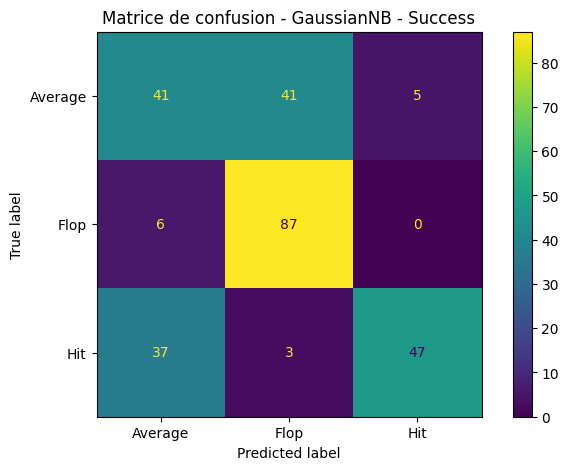

=== Random Forest - Success ===
Accuracy : 0.8764
Precision macro : 0.8758
Recall macro : 0.8755
F1 macro : 0.8756

Classification report :
              precision    recall  f1-score   support

     Average       0.81      0.80      0.81        87
        Flop       0.89      0.91      0.90        93
         Hit       0.92      0.91      0.91        87

    accuracy                           0.88       267
   macro avg       0.88      0.88      0.88       267
weighted avg       0.88      0.88      0.88       267



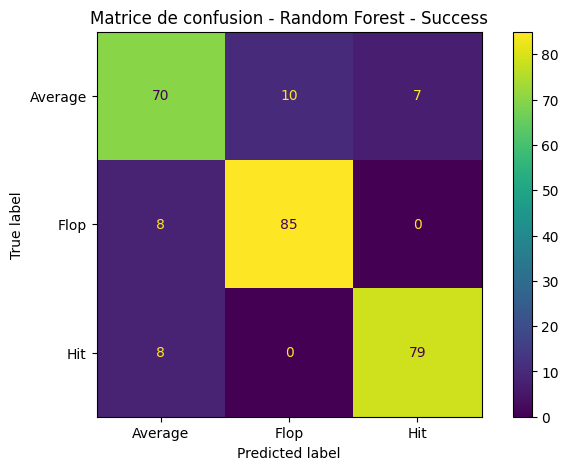

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
1,Random Forest - Success,0.876404,0.875765,0.875541,0.875600
0,GaussianNB - Success,0.655431,0.685355,0.648993,0.644192


In [21]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_success, test_size=0.2, random_state=42, stratify=y_success
)

gnb_success = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', GaussianNB())
])

rf_success = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        class_weight='balanced'
    ))
])

results_success = []
results_success.append(evaluate_model(gnb_success, X_train_s, X_test_s, y_train_s, y_test_s, title='GaussianNB - Success'))
results_success.append(evaluate_model(rf_success, X_train_s, X_test_s, y_train_s, y_test_s, title='Random Forest - Success'))

pd.DataFrame(results_success).sort_values('F1_macro', ascending=False)

## 7. Tâche 2 — Prédiction de la rentabilité

=== GaussianNB - Profitability ===
Accuracy : 0.7079
Precision macro : 0.7528
Recall macro : 0.7079
F1 macro : 0.7054

Classification report :
              precision    recall  f1-score   support

    High ROI       0.69      0.94      0.80        89
     Low ROI       1.00      0.58      0.74        89
  Medium ROI       0.57      0.60      0.58        89

    accuracy                           0.71       267
   macro avg       0.75      0.71      0.71       267
weighted avg       0.75      0.71      0.71       267



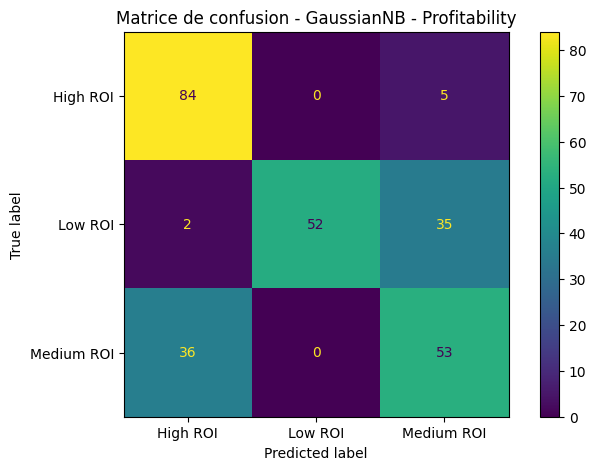

=== Random Forest - Profitability ===
Accuracy : 0.8876
Precision macro : 0.891
Recall macro : 0.8876
F1 macro : 0.8864

Classification report :
              precision    recall  f1-score   support

    High ROI       0.83      0.97      0.90        89
     Low ROI       0.95      0.92      0.94        89
  Medium ROI       0.88      0.78      0.83        89

    accuracy                           0.89       267
   macro avg       0.89      0.89      0.89       267
weighted avg       0.89      0.89      0.89       267



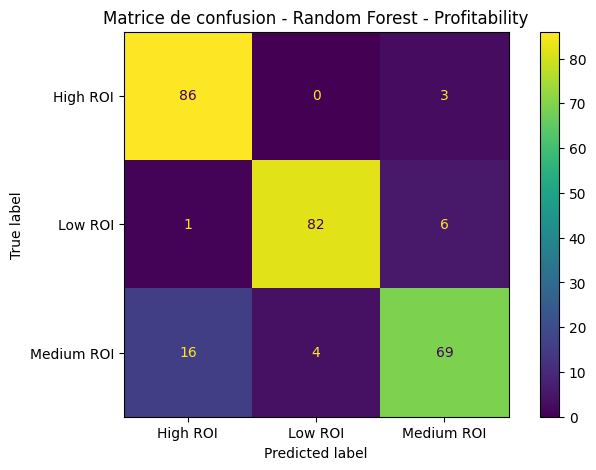

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
1,Random Forest - Profitability,0.887640,0.891018,0.887640,0.886441
0,GaussianNB - Profitability,0.707865,0.752806,0.707865,0.705405


In [22]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_profit, test_size=0.2, random_state=42, stratify=y_profit
)

gnb_profit = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', GaussianNB())
])

rf_profit = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        class_weight='balanced'
    ))
])

results_profit = []
results_profit.append(evaluate_model(gnb_profit, X_train_p, X_test_p, y_train_p, y_test_p, title='GaussianNB - Profitability'))
results_profit.append(evaluate_model(rf_profit, X_train_p, X_test_p, y_train_p, y_test_p, title='Random Forest - Profitability'))

pd.DataFrame(results_profit).sort_values('F1_macro', ascending=False)

## 8. Importance des variables pour Random Forest

In [23]:
rf_success.fit(X_train_s, y_train_s)
rf_model_success = rf_success.named_steps['model']
success_importance = pd.Series(rf_model_success.feature_importances_, index=features).sort_values(ascending=False)
success_importance

Number of Screens    0.424282
Budget(INR)          0.316808
Votes                0.137049
Rating(10)           0.080196
Genre_Encoded        0.041664
dtype: float64

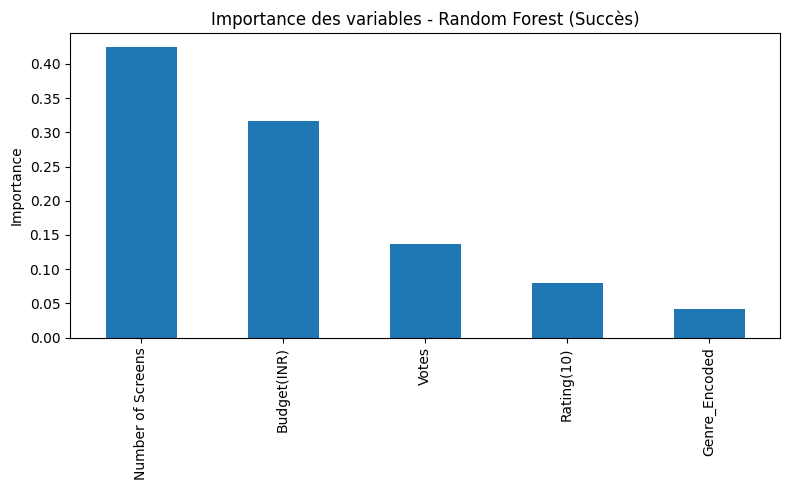

In [24]:
plt.figure()
success_importance.plot(kind='bar')
plt.title("Importance des variables - Random Forest (Succès)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [25]:
rf_profit.fit(X_train_p, y_train_p)
rf_model_profit = rf_profit.named_steps['model']
profit_importance = pd.Series(rf_model_profit.feature_importances_, index=features).sort_values(ascending=False)
profit_importance

Budget(INR)          0.474732
Votes                0.211318
Number of Screens    0.179899
Rating(10)           0.091033
Genre_Encoded        0.043017
dtype: float64

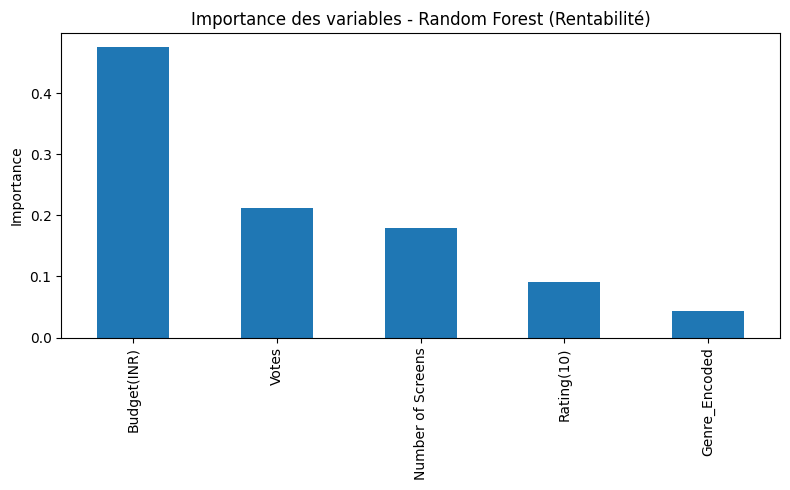

In [26]:
plt.figure()
profit_importance.plot(kind='bar')
plt.title("Importance des variables - Random Forest (Rentabilité)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## 9. Fonction de prédiction pour un nouveau film

In [27]:
# Entraînement final sur l'ensemble complet pour démonstration
final_success_model = rf_success.fit(X, y_success)
final_profit_model = rf_profit.fit(X, y_profit)

def predict_new_movie(genre, budget, screens, rating, votes):
    genre_encoded = genre_encoder.transform([genre])[0]
    sample = pd.DataFrame([{
        'Budget(INR)': budget,
        'Number of Screens': screens,
        'Rating(10)': rating,
        'Votes': votes,
        'Genre_Encoded': genre_encoded
    }])

    success_pred = final_success_model.predict(sample)[0]
    success_proba = final_success_model.predict_proba(sample)[0]
    profitability_pred = final_profit_model.predict(sample)[0]
    profitability_proba = final_profit_model.predict_proba(sample)[0]

    return {
        'success_class': success_pred,
        'success_probabilities': dict(zip(final_success_model.classes_, success_proba)),
        'profitability_class': profitability_pred,
        'profitability_probabilities': dict(zip(final_profit_model.classes_, profitability_proba))
    }

predict_new_movie(
    genre=data['Genre'].iloc[0],
    budget=300_000_000,
    screens=1500,
    rating=7.0,
    votes=15000
)

{'success_class': 'Hit',
 'success_probabilities': {'Average': np.float64(0.37666666666666665),
  'Flop': np.float64(0.0),
  'Hit': np.float64(0.6233333333333333)},
 'profitability_class': 'Low ROI',
 'profitability_probabilities': {'High ROI': np.float64(0.0),
  'Low ROI': np.float64(0.7566666666666667),
  'Medium ROI': np.float64(0.24333333333333335)}}

## 10. Conclusion

- Le projet étudie deux dimensions complémentaires : **succès commercial** et **rentabilité**.
- Les variables `Budget(INR)`, `Number of Screens`, `Rating(10)`, `Votes` et `Genre` permettent d'expliquer une partie importante des différences observées.
- **GaussianNB** sert de modèle simple de référence.
- **Random Forest** fournit généralement une modélisation plus souple et plus performante pour ce type de données tabulaires.
- Le modèle final peut être utilisé pour estimer le profil probable de nouveaux films.